# Skill Dictionary - CareerPath AI 
**Tujuan:** Membangun Skill Dictionary dari dataset yang telah bersih sebagai fondasi mesin pencocokan (Matching Engine) TF-IDF & Cosine Similarity.

---
## Alur Pembuatan Skill Dictionary
1. Load dataset bersih
2. Ekstraksi semua skill dari tiap baris
3. Hitung frekuensi kemunculan tiap skill
4. Susun Skill Dictionary (Skills + Frekuensi)
5. Visualisasi distribusi frekuensi
6. Export ke CSV
7. Validasi hasil akhir


## 1️. Import Library


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

print('Library berhasil diimport!')


Library berhasil diimport!


## 2️. Load Dataset Bersih


In [2]:
df = pd.read_csv('IT_Job_Roles_Skills_Clean.csv')

print(f'Dataset berhasil dimuat!')
print(f'Jumlah profesi : {len(df)} job title')
print(f'Kolom          : {df.columns.tolist()}')
print()
print('Preview 5 baris pertama:')
display(df.head())


Dataset berhasil dimuat!
Jumlah profesi : 30 job title
Kolom          : ['Job Title', 'Skills']

Preview 5 baris pertama:


,Job Title,Skills
0,Artificial intelligence Architect,"ai architecture, machine learning, cloud compu..."
1,Data Analysts,"sql, excel, data visualization, power bi, pyth..."
2,DevOps Engineer,"docker, kubernetes, cicd, aws, azure, linux, t..."
3,Machine Learning Engineer,"python, machine learning, tensorflow, keras, p..."
4,Android Developer,"android sdk, java, kotlin, uiux design, rest a..."


## 3️. Ekstraksi Semua Skill


In [3]:
def extract_all_skills(df, column='Skills'):
    """
    Mengekstrak semua skill dari seluruh baris dataset.
    Setiap baris berisi skill yang dipisahkan koma.
    Fungsi ini memecah dan meratakan semua skill ke dalam satu list.
    """
    all_skills = []
    for skills_str in df[column]:
        skills = [s.strip() for s in str(skills_str).split(',') if s.strip()]
        all_skills.extend(skills)
    return all_skills


all_skills = extract_all_skills(df)

print('Ekstraksi skill selesai!')
print(f'Total skill (termasuk duplikat) : {len(all_skills)}')
print(f'Unique skill                   : {len(set(all_skills))}')
print()
print(f'Contoh 10 skill pertama:')
print(f'{all_skills[:10]}')


Ekstraksi skill selesai!
Total skill (termasuk duplikat) : 255
Unique skill                   : 141

Contoh 10 skill pertama:
['ai architecture', 'machine learning', 'cloud computing', 'data science', 'deep learning', 'systems design', 'aws', 'azure', 'scalability', 'security']


## 4️. Hitung Frekuensi & Susun Skill Dictionary


In [4]:
# Hitung frekuensi kemunculan setiap skill
skill_counter = Counter(all_skills)

# Susun ke dalam DataFrame, diurutkan dari frekuensi tertinggi
skill_dict = pd.DataFrame(
    skill_counter.most_common(),
    columns=['Skills', 'Frekuensi']
).reset_index(drop=True)

# Tambah kolom index mulai dari 1
skill_dict.index = skill_dict.index + 1
skill_dict.index.name = 'No'

print('Skill Dictionary berhasil dibuat!')
print(f'Total skill unik     : {len(skill_dict)}')
print(f'Frekuensi tertinggi  : {skill_dict["Frekuensi"].max()}x  '
      f'({skill_dict.iloc[0]["Skills"]})')
print(f'Frekuensi terendah   : {skill_dict["Frekuensi"].min()}x')
print(f'Skill muncul 1x      : {(skill_dict["Frekuensi"] == 1).sum()} skill')
print(f'Skill muncul > 1x    : {(skill_dict["Frekuensi"] > 1).sum()} skill')
print()
print('Skill Dictionary (urut frekuensi tertinggi):')
display(skill_dict)


Skill Dictionary berhasil dibuat!
Total skill unik     : 141
Frekuensi tertinggi  : 9x  (python)
Frekuensi terendah   : 1x
Skill muncul 1x      : 83 skill
Skill muncul > 1x    : 58 skill

Skill Dictionary (urut frekuensi tertinggi):


,Skills,Frekuensi
No,,
1,python,9
2,cloud computing,7
3,sql,7
4,uiux design,7
5,cicd,5
...,...,...
137,postgresql,1
138,oracle,1
139,database design,1


## 5️. Visualisasi Distribusi Frekuensi


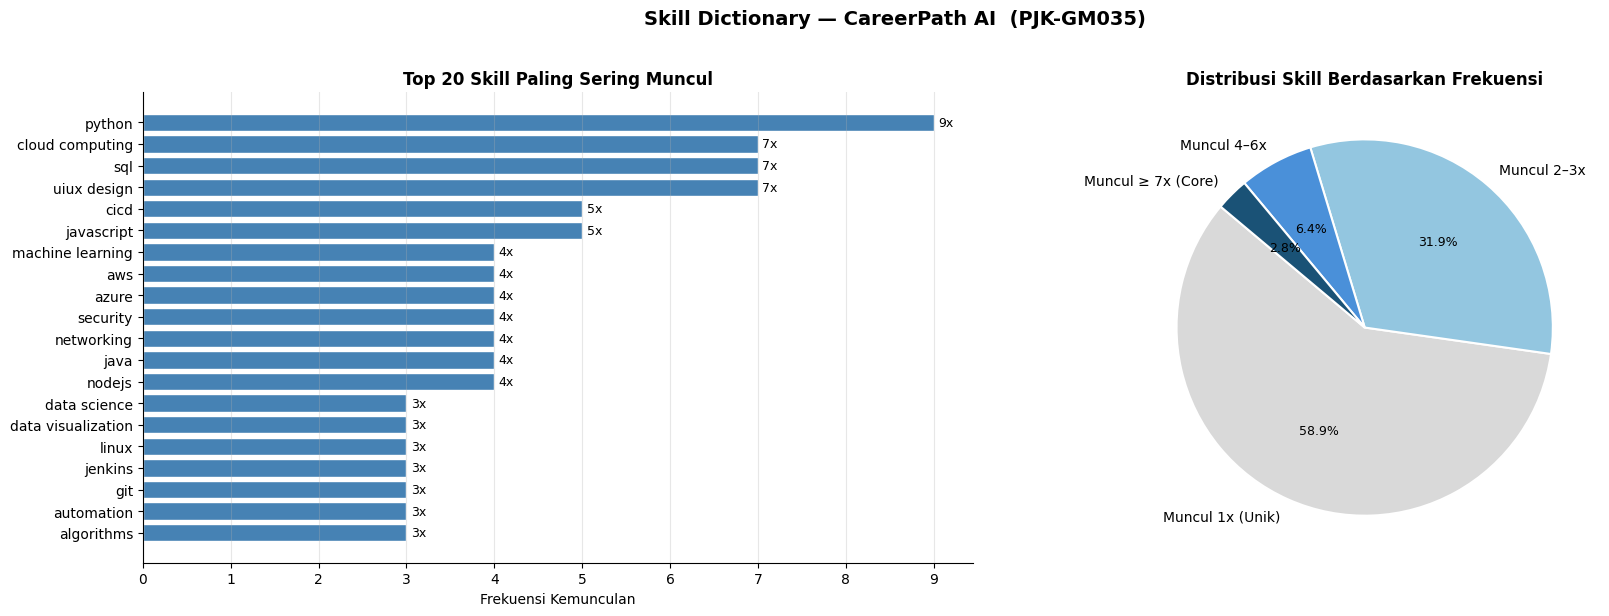

Visualisasi berhasil disimpan ke "skill_dictionary_chart.png"


In [5]:
# ── Visualisasi 1: Top 20 Skill Terbanyak ─────────────────────────────────
TOP_N = 20
top_skills = skill_dict.head(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Skill Dictionary — CareerPath AI  (PJK-GM035)',
             fontsize=14, fontweight='bold', y=1.02)

# --- Bar Chart: Top 20 ---
ax1 = axes[0]
bars = ax1.barh(
    top_skills['Skills'][::-1],
    top_skills['Frekuensi'][::-1],
    color='steelblue', edgecolor='white'
)
ax1.set_title(f'Top {TOP_N} Skill Paling Sering Muncul', fontweight='bold')
ax1.set_xlabel('Frekuensi Kemunculan')
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for bar in bars:
    ax1.text(
        bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}x',
        va='center', ha='left', fontsize=9
    )
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='x', alpha=0.3)

# --- Pie Chart: Distribusi Frekuensi ---
ax2 = axes[1]
freq_groups = {
    'Muncul 1x (Unik)'  : (skill_dict['Frekuensi'] == 1).sum(),
    'Muncul 2–3x'       : ((skill_dict['Frekuensi'] >= 2) & (skill_dict['Frekuensi'] <= 3)).sum(),
    'Muncul 4–6x'       : ((skill_dict['Frekuensi'] >= 4) & (skill_dict['Frekuensi'] <= 6)).sum(),
    'Muncul ≥ 7x (Core)': (skill_dict['Frekuensi'] >= 7).sum(),
}
colors = ['#d9d9d9', '#93c6e0', '#4a90d9', '#1a5276']
wedges, texts, autotexts = ax2.pie(
    freq_groups.values(),
    labels=freq_groups.keys(),
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
ax2.set_title('Distribusi Skill Berdasarkan Frekuensi', fontweight='bold')

plt.tight_layout()
plt.savefig('skill_dictionary_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi berhasil disimpan ke "skill_dictionary_chart.png"')


## 6️. Export Skill Dictionary ke CSV


In [6]:
# Reset index sebelum disimpan agar kolom No ikut tersimpan
df_export = skill_dict.reset_index()

# Simpan ke CSV
OUTPUT_FILE = 'Skill_Dictionary.csv'
df_export.to_csv(OUTPUT_FILE, index=False)

print(f'Skill Dictionary berhasil disimpan ke "{OUTPUT_FILE}"')
print()
print('Preview file yang tersimpan:')
display(pd.read_csv(OUTPUT_FILE).head(10))


Skill Dictionary berhasil disimpan ke "Skill_Dictionary.csv"

Preview file yang tersimpan:


,No,Skills,Frekuensi
0,1,python,9
1,2,cloud computing,7
2,3,sql,7
3,4,uiux design,7
4,5,cicd,5
5,6,javascript,5
6,7,machine learning,4
7,8,aws,4
8,9,azure,4
9,10,security,4


## 7️. Validasi Hasil Akhir


In [7]:
df_val = pd.read_csv('Skill_Dictionary.csv')

print('Laporan Validasi Skill Dictionary:')
print('=' * 45)
print(f'  Total skill unik     : {len(df_val)}')
print(f'  Missing values       : {df_val.isnull().sum().sum()}')
print(f'  Duplikat skill       : {df_val["Skills"].duplicated().sum()}')
print(f'  Kolom                : {df_val.columns.tolist()}')
print('=' * 45)
print()

# Breakdown per kelompok frekuensi
print('Breakdown Kelompok Frekuensi:')
print(f'   Muncul ≥ 7x (Core Skill)  : '
      f'{(df_val["Frekuensi"] >= 7).sum():>3} skill  '
      f'→ {df_val[df_val["Frekuensi"] >= 7]["Skills"].tolist()}')
print(f'   Muncul 4–6x               : '
      f'{((df_val["Frekuensi"] >= 4) & (df_val["Frekuensi"] <= 6)).sum():>3} skill')
print(f'   Muncul 2–3x               : '
      f'{((df_val["Frekuensi"] >= 2) & (df_val["Frekuensi"] <= 3)).sum():>3} skill')
print(f'   Muncul 1x (Skill Spesifik): '
      f'{(df_val["Frekuensi"] == 1).sum():>3} skill')
print()
print('Skill Dictionary siap digunakan!')


Laporan Validasi Skill Dictionary:
  Total skill unik     : 141
  Missing values       : 0
  Duplikat skill       : 0
  Kolom                : ['No', 'Skills', 'Frekuensi']

Breakdown Kelompok Frekuensi:
   Muncul ≥ 7x (Core Skill)  :   4 skill  → ['python', 'cloud computing', 'sql', 'uiux design']
   Muncul 4–6x               :   9 skill
   Muncul 2–3x               :  45 skill
   Muncul 1x (Skill Spesifik):  83 skill

Skill Dictionary siap digunakan!
